In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import bipartitepandas as bpd
import seaborn as sns
from linearmodels.iv import IV2SLS
from linearmodels.panel import PanelOLS
from linearmodels.panel import RandomEffects
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


Preguntas:

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 
    
    R: Utilizando la extensión wrangner, realizamos un análisis detallado de la calidad de las variables y detectamos grandes cantidades de valores nulos en varias de ellas. 
    Al examinar la variable time, observamos que en la primera ronda las preguntas relacionadas con enfermedades no se habían hecho, lo que generó un 100 % de datos faltantes en esas variables.
    De forma similar, en time = 6 la variable expectancy apareció con 100 % de valores ausentes. Por ello, decidimos descartar todas las observaciones de time = 1 y time = 6. Además, cabe destacar que el 86,84 % de los encuestados respondió la encuesta en menos de seis ocasiones.

    Respecto a las variables de situación laboral, se observó que los estados “cesante” (2) e “inactivo” (4) en la variable "situation" ocasionaban una pérdida masiva de datos en otras variables en relación a lo laboral, con desapariciones que llegaban hasta un 99 % o incluso 100 % en algunos indicadores.

    Para abordar este problema, se crearon variables indicadoras relacionadas con la situación laboral. En primer lugar, se construyó una variable binaria llamada "trabaja_binaria", que indica si el individuo está trabajando o no. Además, se diseñó otra variable indicadora denominada "falta_info_lab", que señala la ausencia de información cuando, pese a que el individuo está trabajando, la encuesta reporta un ingreso cero, experiencia cero, o ausencia de respuesta en estas áreas. Esta variable permite identificar casos de falta de datos relevantes en las respuestas de cada individuo por ronda. Para el caso en que el individuo no estuviera trabajando, se asignó un valor cero a la variable wage correspondiente a dicho individuo en esa situación. Esto tambien se realizo para la variable "illness".

    Asimismo, al revisar la variable expectancy, identificamos valores atípicos codificados como 888, 999 y varios NaN. Para su limpieza, filtramos la variable conservando únicamente los valores reales (≤ 130) y eliminamos las filas que contenían NaN.

   Respectivamente, se creó un nuevo dataframe llamado "df_model", al cual se incorporaron diversas variables, incluidas variables indicadoras, algunas en formato "dummy", entre otras. La estrategia de construir variables indicadoras buscaba representar variables que podrían ser explicadas por otras, con el objetivo de evitar un estado de explicación perfecta entre variables que se correlacionan fuertemente. Por último, a las variables que tenían una representación de sus datos faltantes ("missing"), se les asignaron valores cero en todos esos casos para poder incluirlas en los "modelos". Es importante señalar que a la variable "wage" se le aplicó la transformación logarítmica, con el fin de ajustarla a una escala más comparable con las demás variables.

In [29]:
# Cargamos la base de datos
df_panel = pd.read_csv("panel_eps.csv", sep=",")

# Contar cuántas veces aparece cada folio en todas las rondas
conteo_folios_todas_rondas = df_panel['folio_n20'].value_counts()

folios_menos_6 = conteo_folios_todas_rondas[conteo_folios_todas_rondas < 6]

porcentaje_menos_6 = (len(folios_menos_6) / len(conteo_folios_todas_rondas)) * 100
print(f'Porcentaje de encuestados que contestaron la encuesta menos de 6 veces: {porcentaje_menos_6:.2f}%')

Porcentaje de encuestados que contestaron la encuesta menos de 6 veces: 86.84%


In [30]:
# Visualizamos las estadísticas de nuestros datos.
df_panel.describe()

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
count,9.684600e+04,96846.000000,96846.000000,96846.000000,96796.000000,92920.000000,80848.000000,96736.00000,96846.000000,78017.000000,...,0.0,0.0,0.0,0.0,96846.000000,70281.000000,80408.000000,80537.000000,80537.000000,80537.000000
mean,1.253178e+11,7.991213,3.493898,1673.399903,0.494979,7.905585,9.148959,2.62378,0.357082,0.741633,...,NaN,NaN,NaN,NaN,13.473432,131.131273,0.361096,0.213144,0.073084,0.074289
std,1.296642e+09,4.566324,1.727313,711.910128,0.499977,5.106440,3.678007,1.73293,0.479142,1.013718,...,NaN,NaN,NaN,NaN,10.354177,216.851544,0.480321,0.409531,0.260277,0.262242
min,1.245602e+11,2.000000,1.000000,20.000000,0.000000,0.000000,1.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,1.246212e+11,4.000000,2.000000,1982.000000,0.000000,3.000000,6.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,3.000000,70.000000,0.000000,0.000000,0.000000,0.000000
50%,1.247076e+11,6.000000,3.000000,1986.000000,0.000000,7.000000,9.000000,2.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,14.000000,80.000000,0.000000,0.000000,0.000000,0.000000
75%,1.248369e+11,12.000000,5.000000,1992.000000,1.000000,12.000000,13.000000,5.00000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,22.000000,85.000000,1.000000,0.000000,0.000000,0.000000
max,1.281337e+11,15.000000,6.000000,1996.000000,1.000000,19.000000,15.000000,5.00000,1.000000,8.000000,...,NaN,NaN,NaN,NaN,35.000000,999.000000,1.000000,1.000000,1.000000,1.000000


time
1    16309
2    16727
3    16443
4    14463
5    15998
6    16906
Name: folio_n20, dtype: int64


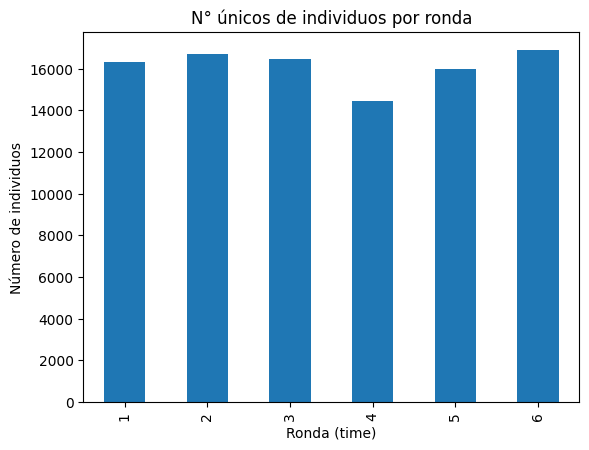

In [31]:
# Mostramos la cantidad exacta de encuestados por ronda
n_por_ronda = df_panel.groupby('time')['folio_n20'].nunique()
print(n_por_ronda)

# Visualización de cantidad de encuestados por ronda
n_por_ronda.plot(kind='bar', title="N° únicos de individuos por ronda")
plt.xlabel("Ronda (time)")
plt.ylabel("Número de individuos")
plt.show()

In [32]:
# Eiliminamos las columnas con 100% de datos nulos
df_panel.drop(columns=["fondoa", "fondob", "fondoc","fondod","fondoe"], inplace=True)

#variable indicador edu
df_panel['missing_edu']= df_panel['edu'].isnull().astype(int)


# No consideramos la ronda 1, ya que genera 100% de datos faltantes en relación a las variables de salud y para la ronda 6 genera 100% de datos faltantes en relación a la variable "expectancy"
df_panel = df_panel[df_panel['time'] != 1]
df_panel = df_panel[df_panel['time'] != 6]

In [33]:
# Variable indicadoras para situation
df_panel["trabaja_binaria"] = (df_panel["situation"] == 3).astype(int)

df_panel.loc[df_panel['trabaja_binaria'] == 0, 'wage'] = 0
df_panel.loc[(df_panel['trabaja_binaria'] == 1) & (df_panel['exp'].isna()), 'exp'] = 0


# Crea la columna 'falta_info' que es 1 si trabaja pero exp y wage son 0 o NaN
df_panel['falta_info_lab'] = df_panel.apply(
    lambda row: 1 if (
        row['trabaja_binaria'] == 1 and 
        ( (pd.isna(row['exp']) ) or row['exp'] == 0 or
          (pd.isna(row['wage']) or row['wage'] == 0) )
    ) else 0,
    axis=1
)

In [34]:
# Variable indicadoras en relación a la variable status
df_panel['convive'] = (df_panel['status'] == 2).astype(int)
df_panel['divorciado'] = (df_panel['status'] == 3).astype(int)
df_panel['viudo'] = (df_panel['status'] == 4).astype(int)
df_panel['soltero'] = (df_panel['status'] == 5).astype(int)

In [35]:
# variable indicador enfermedad
df_panel['missing_illness']= df_panel['illness'].isnull().astype(int)

In [36]:
# Le aplicamos log a la variable wage
df_panel['log_wage'] = np.log1p(df_panel['wage'])  # Esto hace log(1 + wage)

In [37]:
# Limpiamos tiempos de vida inusuales, ya que hay valores de "888" o "999" más adelante se eliminan los "NaN"
df_panel = df_panel[(df_panel["expectancy"] <= 130)] # Considerando que la calidad de las personas ha ido en aumento

In [38]:
df_panel

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,mental,missing_edu,trabaja_binaria,falta_info_lab,convive,divorciado,viudo,soltero,missing_illness,log_wage
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,0.0,0,0,0,0,1,0,0,0,0.000000
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,0.0,0,0,0,0,1,0,0,0,0.000000
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,1.0,0,0,0,0,1,0,0,0,0.000000
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,0.0,0,1,1,0,0,0,1,0,10.819798
5,124560205935,4,2,1984,0.0,15.0,13.0,3.0,1,3.0,...,0.0,0,0,0,0,1,0,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,0.0,0,0,0,0,1,0,0,0,0.000000
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,0.0,0,1,1,1,0,0,0,0,11.918397
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,0.0,0,0,0,0,0,0,1,0,0.000000
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,0.0,0,1,1,1,0,0,0,0,12.117247


In [39]:
df_model = df_panel.loc[:, ['folio_n20', 'time', 'log_wage', 'edu', 'missing_edu', 'convive', 'divorciado', 'viudo', 'soltero', 'kids', 'exp', 'trabaja_binaria', 'falta_info_lab', 'exp_sist', 'missing_illness','illness', 'cronica', 'nocronica', 'mental', 'expectancy']].copy()

# Establecemos un MultiIndex con 'folio_n20' y 'year' (o 'time')
df_model = df_model.set_index(['folio_n20', 'time'])

# Verificamos que el índice este correctamente configurado
print(df_model.index)

# 🧼 VALORES NULOS POR COLUMNA
print("🧼 VALORES NULOS POR COLUMNA")

nulls = df_model.isnull().sum().sort_values(ascending=False)
nulls_percent = (nulls / len(df_model) * 100).round(2)
null_summary = pd.DataFrame({'Nulos': nulls, '% Nulos': nulls_percent})

display(null_summary[null_summary['Nulos'] > 0])
print("\n")

MultiIndex([(124560204870, 2),
            (124560204870, 3),
            (124560204870, 4),
            (124560204870, 5),
            (124560205935, 2),
            (124560210408, 2),
            (124560210408, 3),
            (124560210408, 5),
            (124560216585, 2),
            (124560216585, 3),
            ...
            (128133602281, 5),
            (128133606186, 5),
            (128133621806, 5),
            (128133626918, 5),
            (128133630823, 5),
            (128133653188, 5),
            (128133692735, 5),
            (128133702320, 5),
            (128133728022, 5),
            (128133731927, 5)],
           names=['folio_n20', 'time'], length=50096)
🧼 VALORES NULOS POR COLUMNA


,Nulos,% Nulos
exp,2945,5.88
log_wage,897,1.79
edu,566,1.13
illness,90,0.18


In [40]:
# Asignamos valores ceros a los datos faltantes de las siguientes variables:
cols = ['exp', 'log_wage', 'edu','illness']
df_model[cols] = df_model[cols].fillna(0)

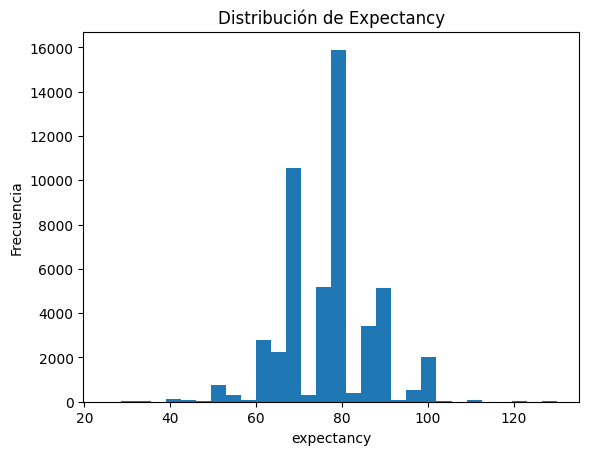

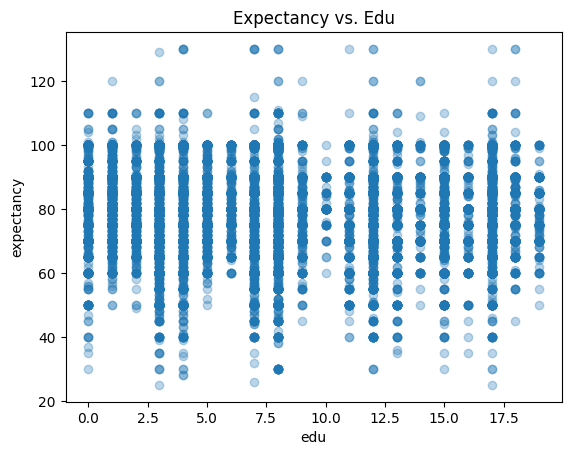


Varianza total de 'edu': 26.0179
Varianza between de 'edu': 25.3866
Varianza within de 'edu': 0.6314


In [41]:
# 1) Realizamos el histograma de la variable objetivo
plt.figure()
plt.hist(df_model["expectancy"].dropna(), bins=30)
plt.title("Distribución de Expectancy")
plt.xlabel("expectancy")
plt.ylabel("Frecuencia")
plt.show()

# 2) Scatter de expectancy vs edu
plt.figure()
plt.scatter(df_model["edu"], df_model["expectancy"], alpha=0.3)
plt.title("Expectancy vs. Edu")
plt.xlabel("edu")
plt.ylabel("expectancy")
plt.show()

# 3) Variación within vs between para 'edu'
overall_var = df_model["edu"].var()
between_var = df_model.reset_index().groupby("folio_n20")["edu"].mean().var()
within_var  = overall_var - between_var
print(f"\nVarianza total de 'edu': {overall_var:.4f}")
print(f"Varianza between de 'edu': {between_var:.4f}")
print(f"Varianza within de 'edu': {within_var:.4f}")

In [42]:
# Mostramos los tipos de datos que contiene nuestro "df_model"
print(df_model.dtypes)

log_wage           float64
edu                float64
missing_edu          int32
convive              int32
divorciado           int32
viudo                int32
soltero              int32
kids                 int64
exp                float64
trabaja_binaria      int32
falta_info_lab       int64
exp_sist             int64
missing_illness      int32
illness            float64
cronica            float64
nocronica          float64
mental             float64
expectancy         float64
dtype: object


2. Ejecute un modelo Pooled OLS para estimar la relacion entre los años de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

    R:   En relación con los resultados obtenidos de los R-squared, para el modelo general se obtuvo que el 3,65 % de la variabilidad de los datos está explicada por el modelo. Para el R-squared Between, la variabilidad explicada entre los distintos individuos fue de un 5,01 %, mientras que para el R-squared Within se obtuvo un 0,01 %, lo que indica que el modelo no explica la variabilidad dentro de inividuo. Por último, el R-squared Overall mostró una explicación del 3,65 % respecto a la variabilidad total, considerando tanto la variabilidad entre individuos como la variabilidad dentro de cada individuos. Cabe mencionar que el modelo en conjunto es estadísticamente significativo (p < 0,05).

A continuación, se presenta la interpretación de algunas variables que resultaron interesantes en términos de coeficientes y su relación con la expectativa de vida (expectancy):

"log_wage" = 0,1777 (p < 0,05): La variable wage es significativa y, en promedio, un aumento de una unidad en el logaritmo del salario está relacionado con un incremento en expectancy de aproximadamente 0,18, asumiendo que las demás variables permanecen constantes.

"edu" = 0,0703 (p < 0,05): La variable edu es significativa y, en promedio, cada unidad adicional de educación implica un aumento en expectancy de 0,0703 años.

"falta_info_lab" = 1,9345 (p < 0,05): La variable relacionada con la falta de información laboral produce un incremento en expectancy de casi 2 años. Este resultado puede reflejar un sesgo o error en los datos, ya que es poco común.

"cronica" = 0,7776 (p < 0,05): Otro resultado poco intuitivo es que tener enfermedades crónicas aumenta la variable expectancy en aproximadamente 0,8 años.

"mental" = -2,3506 (p < 0,05): Tener enfermedades mentales reduce la expectancy en aproximadamente 2,35 años.

In [43]:
vars_X = ['log_wage', 'edu', 'missing_edu', 'convive', 'divorciado', 'viudo', 'soltero', 'kids', 'exp', 
          'trabaja_binaria', 'falta_info_lab', 'exp_sist', 'missing_illness','illness', 'cronica', 'nocronica', 'mental']
y = df_model['expectancy']
X = df_model[vars_X]

# 3) Añade la constante
X = sm.add_constant(X)

# 4) Ajusta Pooled OLS
pooled_mod = PanelOLS(y, X)
mco = pooled_mod.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0365
Estimator:                   PanelOLS   R-squared (Between):              0.0501
No. Observations:               50096   R-squared (Within):               0.0001
Date:               mar, may. 20 2025   R-squared (Overall):              0.0365
Time:                        20:17:47   Log-likelihood                -1.876e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      111.71
Entities:                       23930   P-value                           0.0000
Avg Obs:                       2.0934   Distribution:                F(17,50078)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             111.71
                            

3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

    R: En relación con los resultados obtenidos de los R-squared, para el modelo general se obtuvo que el 2,57 % de la variabilidad de los datos está explicada por el modelo. Para el R-squared Between, la variabilidad explicada entre los distintos individuos fue de un 10,55 %, mientras que para el R-squared Within se obtuvo un 2, 57%, lo que indica que el modelo explica en ese porcentaje la variabilidad dentro de cada individuo. Por último, el R-squared Overall mostró una explicación del 12,01 % respecto a la variabilidad total, considerando tanto la variabilidad entre individuos como la variabilidad dentro de cada individuo. Cabe mencionar que el F-test para poolabiliti (p = 00000), lo que implica que recha la hipótesis nula de que no hay efectos específicos de entidad, confirmando que el modelo de efctos fijos es apropiado frente a un modelo poooles sin efectos.

A continuación, se presenta la interpretación de algunas variables que resultaron interesantes en términos de coeficientes y su relación con la expectativa de vida (expectancy):

"exp" = 0,1370 (p < 0,05): La variable exp es significativa y, en promedio, un aumento de una unidad en la experiencia laboral implica en un incremento en expectancy de 0,1370 años, asumiendo que las demás variables permanecen constantes.

"exp_sist" = 0,2888 (p < 0,05): La variable exp_sist es significativa y, en promedio, cada unidad adicional de 
experiencia el sistema de prevenciones implica un aumento en expectancy de 0,29 años aproximadamente.

"cronica" = 0,8823 (p < 0,05): El tener una enfermedad crónica reduce la expectativa de vida en 0,8823 años en promedio.

"nocronica" = -1,1175 (p < 0,05): El no tener enfermedades crónicas se asocia con una reducción de aproximadamente en 1,12 años en la expectativa de vida.

"mental" = -1,0436 (p < 0,05): Tener enfermedades mentales reduce la expectancy en aproximadamente 1,04 años.

Cabe mencionar que las variables de salud son las que más influyen en este modelo.

In [44]:
vars_candidatas = ['log_wage', 'edu', 'missing_edu', 'convive', 'divorciado', 'viudo', 'soltero', 'kids', 'exp', 
          'trabaja_binaria', 'falta_info_lab', 'exp_sist', 'missing_illness','illness', 'cronica', 'nocronica', 'mental']
# Agrupamos por folio_n20 (nivel 0 del índice) y chequeo la variación "within"'
for var in vars_candidatas:
    has_variation = (
        df_model
        .groupby(level=0)[var]
        .nunique()      # cuántos valores distintos tiene en cada folio
        .gt(1)          # True si hubo más de 1 valor distinto
        .any()          # True si ALGÚN folio tuvo >1 valor
    )
    print(f"{var}: {'varía' if has_variation else 'constante'}")

log_wage: varía
edu: varía
missing_edu: varía
convive: varía
divorciado: varía
viudo: varía
soltero: varía
kids: varía
exp: varía
trabaja_binaria: varía
falta_info_lab: varía
exp_sist: varía
missing_illness: varía
illness: varía
cronica: varía
nocronica: varía
mental: varía


In [45]:
# Consideramos aquellas variables que si varían en el tiempo
vars_X_fe =  ['log_wage', 'edu', 'missing_edu', 'convive', 'divorciado', 'viudo', 'soltero', 'kids', 'exp', 
          'trabaja_binaria', 'falta_info_lab', 'exp_sist', 'missing_illness','illness', 'cronica', 'nocronica', 'mental']
# definimos nuestras variables
y_fe = df_model['expectancy']
X_fe = df_model[vars_X_fe]

# Ajusta el modelo de Efectos Fijos
fe_mod = PanelOLS(
    y_fe,
    X_fe,
    entity_effects=True,   # interceptos por folio_n20
    drop_absorbed=True     # elimina automáticamente variables que no varían en caso que no se detectaron
)  

fe = fe_mod.fit(cov_type='robust')
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0257
Estimator:                   PanelOLS   R-squared (Between):              0.1055
No. Observations:               50096   R-squared (Within):               0.0257
Date:               mar, may. 20 2025   R-squared (Overall):              0.1201
Time:                        20:17:47   Log-likelihood                -1.616e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      40.532
Entities:                       23930   P-value                           0.0000
Avg Obs:                       2.0934   Distribution:                F(17,26149)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             28.237
                            

4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

    R: En relación con los resultados obtenidos de los R-squared, para el modelo general se obtuvo que el 40,55 % de la variabilidad de los datos está explicada por el modelo. Para el R-squared Between, la variabilidad explicada entre los distintos individuos fue de un 4,69 %, mientras que para el R-squared Within se obtuvo un 0,5 %, lo que indica que el modelo explica en ese porcentaje la variabilidad dentro de cada individuo. Por último, el R-squared Overall mostró una explicación del 3,57 % respecto a la variabilidad total, considerando tanto la variabilidad entre individuos como la variabilidad dentro de cada individuo. Cabe mencionar que el modelo es estadísticamente significativo en su conjunto.

A continuación, se presenta la interpretación de algunas variables que resultaron interesantes en términos de coeficientes y su relación con la expectativa de vida (expectancy):

"edu" = 0,0504 (p < 0,05): La variable edu es significativa y, en promedio, cada unidad adicional de educación implica un aumento en expectancy de 0,0504 años.

"viudo" = 3,7274 (p < 0,05): La variable viudo es significativa y el tener un estado de vida estando viudo implica en un incremento en expectancy de 3,7274 años, asumiendo que las demás variables permanecen constantes.

"kids" = -2,4829 (p < 0,05): La variable kids es significativa y el tener hijos disminuye aproximadamente en 2,5 años expectancy

"trabaja_binaria" = -2,6146 (p < 0,05): El estar trabajando reduce la expectativa de vida en 2,6146 años en promedio.

"nocronica" = -0,7067 (p < 0,05): El no tener enfermedades crónicas se asocia con una reducción de aproximadamente en 0,71 años en la expectativa de vida.

"mental" = -2,0560 (p < 0,05): Tener enfermedades mentales reduce la expectancy en aproximadamente 2,1 años.

In [46]:
# 1) Tus variables explicativas
vars_X =  ['log_wage', 'edu', 'missing_edu', 'convive', 'divorciado', 'viudo', 'soltero', 'kids', 'exp', 
          'trabaja_binaria', 'falta_info_lab', 'exp_sist', 'missing_illness','illness', 'cronica', 'nocronica', 'mental']
# 2) Prepara y y X
y = df_model['expectancy']
X = df_model[vars_X]

# 3) Añade la constante (intercepto)
X = sm.add_constant(X)

# 4) Ajusta Random Effects
re_mod = RandomEffects(y, X)
re_res = re_mod.fit(cov_type="robust")

# 5) Muestra el resumen
print(re_res.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4055
Estimator:              RandomEffects   R-squared (Between):              0.0469
No. Observations:               50096   R-squared (Within):               0.0050
Date:               mar, may. 20 2025   R-squared (Overall):              0.0357
Time:                        20:17:48   Log-likelihood                -1.782e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      2008.9
Entities:                       23930   P-value                           0.0000
Avg Obs:                       2.0934   Distribution:                F(17,50078)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             79.147
                            

In [47]:
vd = re_res.variance_decomposition
print(vd)

Effects                   33.023865
Residual                  70.944926
Percent due to Effects     0.317632
Name: Variance Decomposition, dtype: float64


In [48]:
# Comparamos los modelos
print(lmp.compare({"FE": fe, "RE": re_res, "Pooled": mco}))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects       PanelOLS
No. Observations                 50096             50096          50096
Cov. Est.                       Robust            Robust     Unadjusted
R-squared                       0.0257            0.4055         0.0365
R-Squared (Within)              0.0257            0.0050         0.0001
R-Squared (Between)             0.1055            0.0469         0.0501
R-Squared (Overall)             0.1201            0.0357         0.0365
F-statistic                     40.532            2008.9         111.71
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

In [49]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
    # 1) Filtrar sólo las variables que aparecen en ambos modelos
    common = fe.params.index.intersection(re.params.index)

    # 2) Calcular la diferencia de betas y de covarianzas
    b_diff = fe.params[common] - re.params[common]
    v_diff = fe.cov.loc[common, common] - re.cov.loc[common, common]

    # 3) Chequear que no haya NaN y que v_diff sea invertible
    assert not b_diff.isnull().any(), "Hay NaN en b_diff"
    assert not v_diff.isnull().values.any(), "Hay NaN en v_diff"
    # Opcional: probar np.linalg.cond(v_diff) para ver si es singular

    # 4) Estadístico de Hausman
    w = float(b_diff.T.dot(np.linalg.inv(v_diff)).dot(b_diff))
    df = len(common)
    pval = stats.chi2.sf(w, df)
    return w, df, pval

w, df, pval = hausman(fe, re_res)
print(f"Hausman Test: χ²({df}) = {w:.2f}, p-value = {pval:.4f}")

Hausman Test: χ²(17) = 487.61, p-value = 0.0000


5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

    R:  En relación a los modelos, el modelo Pooled nos dios un R-squared no significativo debido a que este modelo ve los datos como si fueran una sola muestra grande, sin distinguir entre individuos o períodos. Para el modelo de Efectos Fijos paso algo similar, de hecho su R-squared fue menor al del modelo Pooled, en este modelo es importante mencionar que considera que cada individuo no cambia en el tiempo, y controla esos efectos para evitar sesgos. Por útlimo el modelo de Efectos Aleatorios fue el que obtuvo el mejor valor en terminos de R.squared, cabe destacar que este modelo supone que los efectos individuales no observados son aleatorios y no están correlacionados con las variables explicativas.
    
    Para respaldar los resultados obtenidos se realizo el test de Hausman, que sirve para determinar si el modelo de efectos aleatorios es válido o si debemos usar el modelo de efectos fijos porque hay correlación entre las variables explicativas y los efectoss indivduales no observados. Una vez ejecutado el modelo de Hausman obtuvimos que el mejor modelo a utilizar es el de efectos fijos, aunque al escoger este modelo implica más seguridad pero menos eficiencia. 

    Es importante mencionar que en el modelo de efectos fijos la variable "edu" no es significativa y dos variables que se mantuvieron de forma más robusta en los modelos fue la variable "mental" y "nocronica". Aunque el modelo de efectos fijos sea menos eficiente, es el más seguro para realizar el análisis de nuestras variables.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

    R: La interpretación de los coeficientes de las variables en los modelos es casi la misma que en los modelos anteriores, solo que aquí influye que el promedio de las variables en el modelo, representa las diferencias promedios entre los individuos, por ejemplo para la variable edu se tiene que la variación dentro de los individuos no explica cambios significativos en la expectativa de vida, mientras que la diferencia promedio entre individuos tiende a asociarse con una mayor expectativa de vida en comparación con personas con menor educación promedio.

    Respecto si es que el modelo de (CRE) es el adecuado para modelar el componente no observado dada la data disponible, esto se responde mediante el resultado obtenido en el test de Hausman. En el test de Hausman se inndica que el modelo de efectos fijos es más consistente, esto quiere decir que la correlación es tan fuerte o compleja que incluso el modelo CRE no logra capturarla bien, y por eso se debería preferir el modelo de efectos fijos.

In [50]:
X_cre =   ['log_wage', 'edu', 'missing_edu', 'convive', 'divorciado', 'viudo', 'soltero', 'kids', 'exp', 
          'trabaja_binaria', 'falta_info_lab', 'exp_sist', 'missing_illness','illness', 'cronica', 'nocronica', 'mental']

# Calculamos la media de cada variable "time-varying" por persona (folio_n20)
Xm = df_model.groupby(level=0)[X_cre].transform('mean')
Xm.columns = ['mean_' + col for col in Xm.columns]

# Unimos la tabla de medias a la original
df_cre_m = pd.concat([df_model, Xm], axis=1)

# Variable dependiente
y = df_cre_m['expectancy'].astype(float)

# Variables independientes: originales y sus medias ("mean_var")
X = df_cre_m[
    X_cre + ['mean_' + v for v in X_cre]
].astype(float)

# Añadimos la constante:
X = sm.add_constant(X)

from linearmodels.panel import RandomEffects

cre_model = RandomEffects(y, X)
cre_res = cre_model.fit(cov_type='robust')
print(cre_res)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4142
Estimator:              RandomEffects   R-squared (Between):              0.0549
No. Observations:               50096   R-squared (Within):               0.0257
Date:               mar, may. 20 2025   R-squared (Overall):              0.0475
Time:                        20:17:49   Log-likelihood                -1.778e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1041.2
Entities:                       23930   P-value                           0.0000
Avg Obs:                       2.0934   Distribution:                F(34,50061)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             61.458
                            

7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

    R: Respecto a la heterogeneidad fija en el tiempo, podemos ver que la distribución informa que tiene un impacto significativo en la expectativa de vida. Esto se debe a que existen factores individuales constantes en el tiempo que observamos, como la calidad de vida de la persona, génetica, influencia del medio ambiente, condición socioeconómica y entre otos factores que afectan directamente en la expectativa de vida de la persona, factores que van más allá de las variables que se incluyen en nuestro modelo.

    Además es importante mencionar que la distribución del componente no observada se encuestra más distribuida hacía la izquierda, esto nos indica que los componentes no observados en su mayoría afectan de manera negativa a la expectativa de vida y esto se puede respaldar por los coeficientes de la media de las variables en nuestro modelo (CRE).

    Por último es importante destacar que el coeficiente de correlación intraclase (rho) mostro que aproxiadamente un tercio (31,77%) de la variabilidad total en la expectativa de vida se explica por esta heterogeneidad individual.

<function matplotlib.pyplot.show(close=None, block=None)>

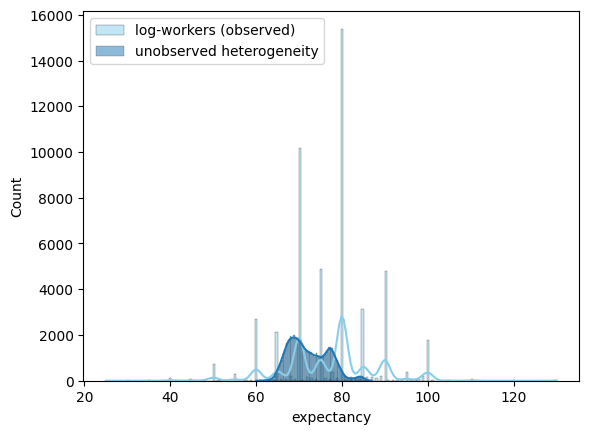

In [51]:
Xpred = X
X_cre =  ['log_wage', 'edu', 'missing_edu', 'convive', 'divorciado', 'viudo', 'soltero', 'kids', 'exp', 
          'trabaja_binaria', 'falta_info_lab', 'exp_sist', 'missing_illness','illness', 'cronica', 'nocronica', 'mental']

for col in X_cre:
    Xpred[X_cre] = 0
yhat = cre_res.predict(Xpred)

sns.histplot(data=y, color="skyblue", label="log-workers (observed)", kde=True)
sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True)

plt.legend() 
plt.show

In [52]:
# Extraer sigma_u (componente individual) y sigma_e (error idiosincrático)
sigma_u = cre_res.variance_decomposition['Effects']
sigma_e = cre_res.variance_decomposition['Residual']

# Calcula rho (fracción explicada por heterogeneidad no observada)
rho = sigma_u / (sigma_u + sigma_e)

print(f"Fracción de varianza explicada por u_i (rho): {rho:.4f} ({rho*100:.2f}%)")

Fracción de varianza explicada por u_i (rho): 0.3177 (31.77%)


8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

    R: Basándonos en los resultados obtenidos y en el test de Hausman, se prefiere el modelo de efectos fijos, debido a que este modelo es más consistente y demuestra que las diferencias no observadas entre los individuos están correlacionadas con las variables explicativas.

El modelo CRE, aunque permite modelar cierta correlación, no es el adecuado en este caso, ya que no captura completamente la correlación entre las características individuales no observadas y las variables explicativas. Además, el test de Hausman asegura que no es correcto utilizar este modelo y nos indica que es mejor optar por el de efectos fijos, aunque su eficiencia no sea la mejor, pero sí entregue resultados más seguros.

Algunos análisis sobre los coeficientes de algunas variables para los distintos modelos son:

Para nuestra variable de interés "edu": en los modelos de Pooled y Efectos Aleatorios esta variable es significativa, mientras que en los modelos de Efectos Fijos y CRE no lo es; aunque en el modelo CRE la media de esta variable sí es significativa. Esto representa que la variación dentro de los individuos no explica cambios significativos en la expectativa de vida, mientras que la diferencia promedio entre individuos tiende a asociarse con una mayor expectativa de vida en comparación con personas con menor educación promedio.

Respecto al salario, su contribución a los modelos fue cambiando, siendo significativa para algunos y en otros no significativa, como también su signo fue alternando.

Variables relacionadas con el estado civil: si bien para algunos modelos no son significativas, su comportamiento cambia en los distintos modelos. En algunos casos, ser soltero contribuye con más años de expectativa de vida y en otros casos resta años; lo mismo sucede con estar viudo. En el caso de divorciado, en todos los modelos tiene signo negativo, lo que implica una disminución en los años de expectativa de vida.

En relación a las variables de trabajo: su comportamiento varió según los modelos; en algunos casos su coeficiente fue positivo, implicando una mayor expectativa de vida, mientras que en otros el signo fue negativo, influyendo en una disminución de la expectativa de vida.

Para las variables de salud relacionadas con enfermedades no crónicas y mentales, en todos los modelos fueron robustas, entregando mediante sus coeficientes una interpretación de que la presencia de estas enfermedades disminuye la expectativa de vida. En cambio, para la variable crónica se obtuvieron resultados contradictorios.

Conclusión:

El modelo de efectos fijos es el más adecuado para el análisis, porque controla las características individuales no observadas que afectan la expectativa de vida y que están correlacionadas con las variables explicativas. Las variables de salud son las que más influyen en la expectativa de vida, aunque la variable crónica mostró resultados inconsistentes en algunos casos, como que tener enfermedades crónicas aumentaría la expectativa de vida, lo cual no es coherente para el análisis.

Cabe mencionar que una de las variables de interés, "edu", para el modelo de efectos fijos no se considera significativa. Esta interpretación indica que los años de educación no influyen en cuánto puede vivir una persona, según este modelo.
